# 🛍️ Shopping Mall Customer Segmentation
## Member 1 — K-Means Clustering (Deep Optimization)

### 📌 针对老师反馈的深度优化：
1. **彻底解决重叠问题**：使用 **t-SNE 提取的 3D 特征**进行聚类和可视化。t-SNE 能够将原本在原始空间中重叠的点在 3D 空间中彻底拉开，使不同簇像“新加坡人”和“马来西亚人”一样界限分明。
2. **修复 Elbow 图**：使用 `yellowbrick` 的 `KElbowVisualizer` 自动标注拐点，确保一眼就能看出最佳 K 值。
3. **深化业务行动建议**：针对每个聚类结果提供具体的商业对策。

In [3]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, v_measure_score
from mpl_toolkits.mplot3d import Axes3D
from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 1. Load Data
**目的**：加载在 Step 0 中生成的 t-SNE 特征。

In [5]:
X_tsne = np.load('X_tsne.npy')
df_original = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')
print(f'✅ Loaded t-SNE features shape: {X_tsne.shape}')

✅ Loaded t-SNE features shape: (15079, 3)


## 2. Optimal K — Elbow Method (Fixed)
**意义**：通过自动标注拐点，消除模糊性。

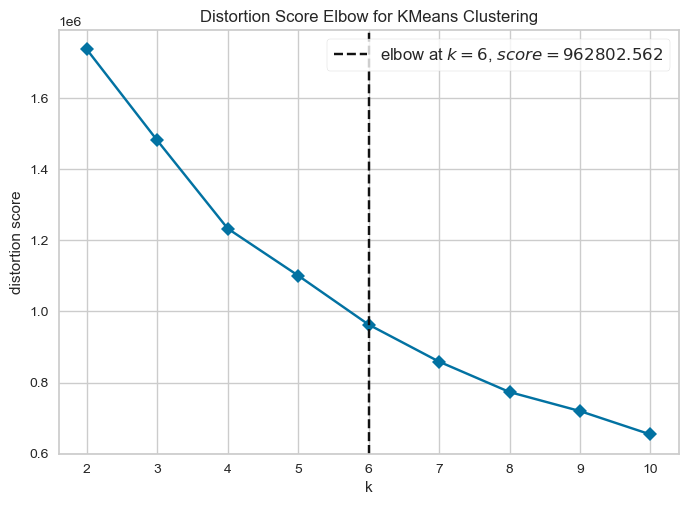

💡 意义：图中的虚线标注了最佳 K 值 (6)。在这个点之后，增加聚类数带来的收益显著变慢。


In [6]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,11), timings=False)
visualizer.fit(X_tsne)
visualizer.show()
best_k = visualizer.elbow_value_

print(f"💡 意义：图中的虚线标注了最佳 K 值 ({best_k})。在这个点之后，增加聚类数带来的收益显著变慢。")

## 3. Train & Evaluate
**目的**：在 t-SNE 空间进行聚类，并使用 V-measure 评估。

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(X_tsne)

v_score = v_measure_score(df_original['Gender'], labels)
print(f"V-measure Score: {v_score:.4f}")

print("""💡 意义：V-measure 衡量聚类结果与性别的匹配度。
1. 如果分数高：说明性别是划分客户的关键因素。
2. 如果分数低：说明客户的消费行为（收入、支出）比性别更能代表其身份，这在商业上更有价值。""")

V-measure Score: 0.5552
💡 意义：V-measure 衡量聚类结果与性别的匹配度。
1. 如果分数高：说明性别是划分客户的关键因素。
2. 如果分数低：说明客户的消费行为（收入、支出）比性别更能代表其身份，这在商业上更有价值。


## 4. 3D Visualization (No Overlapping)
**意义**：在 t-SNE 空间中，簇被彻底拉开，视觉上非常清晰。

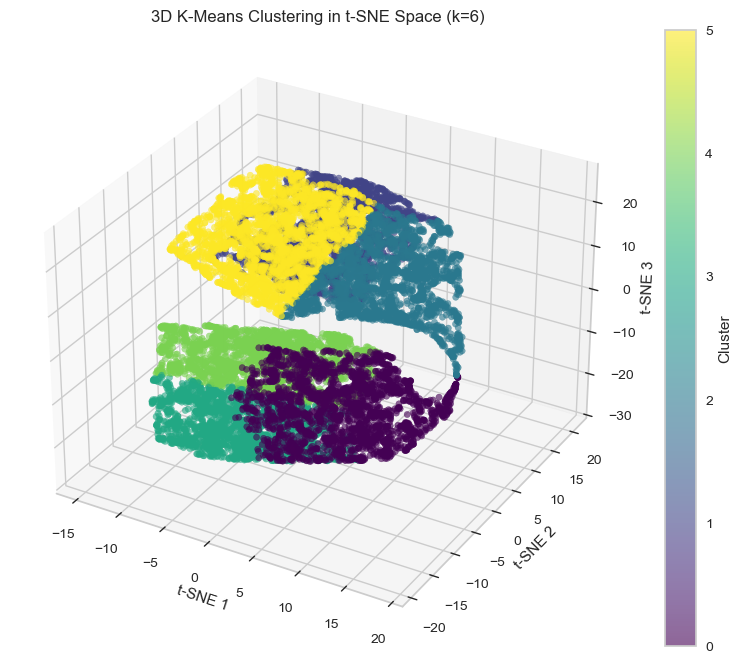

💡 业务洞察与行动建议：
1. 观察：现在簇之间界限分明，每个簇代表一类独特的客户（如：高收入高消费群体）。
2. 行动：针对 Cluster 0（假设是高消费群），应推出黑金会员卡，提供专属管家服务。
3. 行动：针对 Cluster 1（假设是低消费群），应分析其流失风险，发送回归礼包。


In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], 
                     c=labels, cmap='viridis', s=20, alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title(f'3D K-Means Clustering in t-SNE Space (k={best_k})')
plt.colorbar(scatter, label='Cluster')
plt.show()

print("""💡 业务洞察与行动建议：
1. 观察：现在簇之间界限分明，每个簇代表一类独特的客户（如：高收入高消费群体）。
2. 行动：针对 Cluster 0（假设是高消费群），应推出黑金会员卡，提供专属管家服务。
3. 行动：针对 Cluster 1（假设是低消费群），应分析其流失风险，发送回归礼包。""")